In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [132]:
df_avg = pd.read_csv("../../../data/processed/3_year/Forwards/Avg_Top5_Forwards.csv")

In [133]:
df_avg.head()

,player id,player,team,team id,league,position,number_of_seasons,keypasses,minutesplayed,offsides,...,aerialduelswon_per90,aeriallost_per90,shots_on_target_pct,inside_box_shot_pct,assist_conversion,xa_per_keypass,final_third_pass_pct,possession_lost_per_touch,defensive_actions_per90,weak_foot_goals_pct
0,19356,Iago Aspas,Celta Vigo,2821,Spain La Liga,Forwards,3,53.333333,1872.333333,5.666667,...,0.304433,0.769094,0.402516,0.647799,0.112500,0.106875,0.476773,0.262911,4.342176,0.125000
1,32048,Cristhian Stuani,Girona FC,24264,Spain La Liga,Forwards,3,6.000000,768.333333,7.000000,...,2.537961,2.303688,0.551724,0.965517,0.277778,0.109444,0.288793,0.268139,2.967462,0.181818
2,33902,Danny Welbeck,Brighton & Hove Albion,30,England Premier League,Forwards,3,21.666667,2031.000000,6.000000,...,0.768095,1.344165,0.433121,0.757962,0.092308,0.064000,0.383797,0.232112,3.648449,0.304348
3,34120,Alexis Sánchez,Sevilla,2833,Spain La Liga,Forwards,3,15.666667,841.333333,8.333333,...,0.891442,1.675911,0.300000,0.760000,0.148936,0.102553,0.486226,0.294406,5.455626,0.000000
4,35428,Pedro,Lazio,2699,Italy Serie A,Forwards,3,20.000000,967.666667,1.666667,...,0.155012,0.620048,0.458333,0.472222,0.066667,0.080667,0.331169,0.213972,6.107475,0.400000


In [134]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons'])

In [135]:
X_avg.head()

,keypasses,offsides,possessionlost,accuratecrossespercentage,accuratelongballspercentage,successfuldribblespercentage,goalconversionpercentage,penaltyconversion,aerialduelswonpercentage,groundduelswonpercentage,...,aerialduelswon_per90,aeriallost_per90,shots_on_target_pct,inside_box_shot_pct,assist_conversion,xa_per_keypass,final_third_pass_pct,possession_lost_per_touch,defensive_actions_per90,weak_foot_goals_pct
0,53.333333,5.666667,317.333333,28.191489,61.792453,66.666667,15.094340,76.923077,28.358209,47.319347,...,0.304433,0.769094,0.402516,0.647799,0.112500,0.106875,0.476773,0.262911,4.342176,0.125000
1,6.000000,7.000000,56.666667,0.000000,25.000000,45.454545,28.735632,85.714286,52.419355,26.976744,...,2.537961,2.303688,0.551724,0.965517,0.277778,0.109444,0.288793,0.268139,2.967462,0.181818
2,21.666667,6.000000,181.666667,0.000000,60.000000,37.647059,17.834395,50.000000,36.363636,36.853448,...,0.768095,1.344165,0.433121,0.757962,0.092308,0.064000,0.383797,0.232112,3.648449,0.304348
3,15.666667,8.333333,140.333333,18.750000,67.123288,50.000000,12.000000,100.000000,34.722222,41.111111,...,0.891442,1.675911,0.300000,0.760000,0.148936,0.102553,0.486226,0.294406,5.455626,0.000000
4,20.000000,1.666667,146.000000,24.347826,64.197531,53.750000,22.222222,100.000000,20.000000,47.416413,...,0.155012,0.620048,0.458333,0.472222,0.066667,0.080667,0.331169,0.213972,6.107475,0.400000


In [136]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)

In [137]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

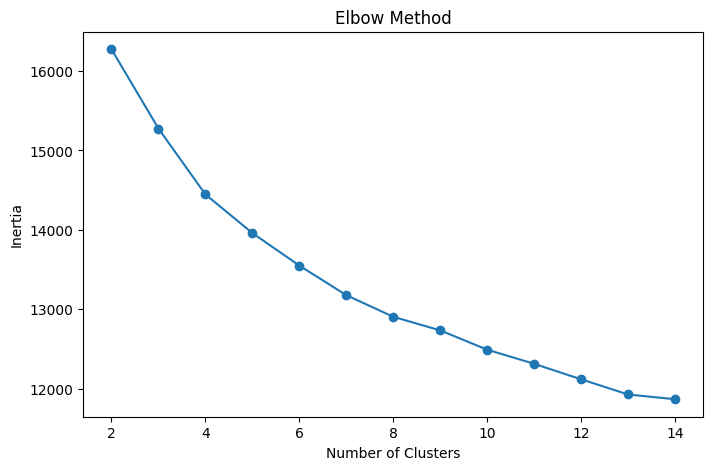

In [138]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [139]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

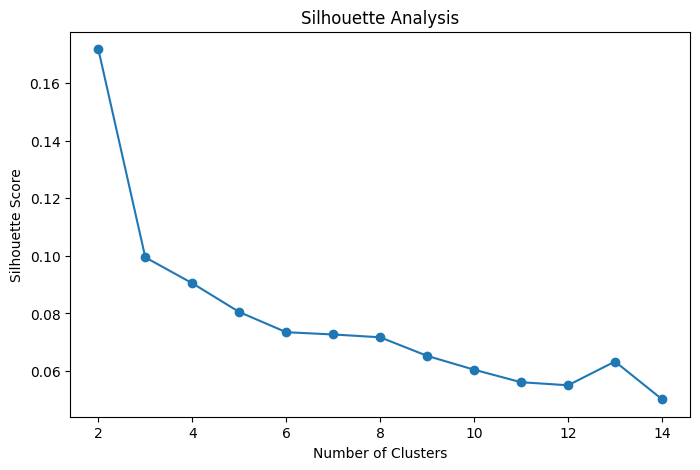

In [140]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [141]:
x=4
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [142]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby(f"cluster_{x}").mean())

display(cluster_avg_summary.transpose())

cluster_4,0,1,2,3
number_of_seasons,2.626374,2.542857,2.242424,2.322581
keypasses,18.478022,35.754762,13.489899,16.649194
minutesplayed,1626.721612,1659.669048,1403.872475,1262.568548
offsides,11.054945,5.290476,9.228535,4.868280
possessionlost,191.382784,285.076190,182.972222,193.544355
accuratecrossespercentage,16.900370,25.065535,17.068742,20.922768
accuratelongballspercentage,55.971643,59.438619,54.534434,50.715812
successfuldribblespercentage,41.924072,48.897731,40.549350,42.758985
goalconversionpercentage,19.046141,12.567460,13.518427,10.115571
penaltyconversion,62.113320,59.098850,36.203935,13.077957


In [143]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"cluster_{x}",
    hover_name='player',         
    hover_data=['team','goals_per90','expectedgoals_per90'], 
    title=f"Forwards Avg Clusters (K={x})",
    width=1000,
    height=700
)

fig.show()

### 4 Clusters chosen as 5 clusters were causing 2 outliers to be created into a new cluster ###

In [144]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [145]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [146]:
pca_sizes = range(10,25)

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [147]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(4, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [148]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,10,4,0.132709
7,11,4,0.128162
14,12,4,0.121742
1,10,5,0.119163
21,13,4,0.117922
8,11,5,0.115975
28,14,4,0.114945
3,10,7,0.114824
2,10,6,0.113348
35,15,4,0.111404


In [149]:
x=10
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
keypasses,0.138851,0.229859,0.091253,-0.010708,-0.112664,-0.168690,0.047927,0.264498,0.050583,-0.067981
offsides,-0.138480,0.129466,0.095840,0.045221,-0.047937,-0.169292,-0.091313,0.330929,0.080436,-0.001916
possessionlost,0.091050,0.154132,0.184481,-0.080809,-0.102882,-0.254953,0.117444,0.281905,0.085460,-0.017454
accuratecrossespercentage,0.093284,0.005546,-0.045869,-0.023126,-0.011322,-0.104486,0.043053,0.089501,0.053330,-0.203236
accuratelongballspercentage,0.014480,0.109762,-0.018581,-0.039716,0.040369,0.082725,0.043080,0.180197,0.213841,-0.262723
successfuldribblespercentage,0.107436,0.091966,-0.008540,-0.106693,-0.009074,0.154597,0.050827,0.229517,0.007068,-0.184321
goalconversionpercentage,-0.137274,0.208267,-0.168496,-0.006930,0.019748,-0.002072,0.390791,-0.013175,-0.071015,0.050061
penaltyconversion,-0.043695,0.208339,-0.035467,-0.128394,-0.111941,-0.132226,0.078443,0.192879,0.217539,0.365056
aerialduelswonpercentage,-0.111821,0.055163,0.242115,-0.169588,-0.212185,0.181309,-0.005045,0.001899,-0.103439,-0.067873
groundduelswonpercentage,0.246257,0.064784,-0.053395,-0.014846,0.031949,0.253752,-0.009142,0.126941,-0.057919,0.032685


In [150]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
touches_per90               0.254775
groundduelswonpercentage    0.246257
totalcross_per90            0.234250
groundduelswon_per90        0.221755
defensive_actions_per90     0.219678
expectedassists_per90       0.218778
inside_box_shot_pct         0.218607
possessionlost_per90        0.206390
successfuldribbles_per90    0.206044
aeriallost_per90            0.197983
Name: PC1, dtype: float64

PC2
goals_per90                    0.316923
shotsontarget_per90            0.301822
expectedgoals_per90            0.283075
penaltygoals_per90             0.252982
keypasses                      0.229859
shotsfrominsidethebox_per90    0.226385
duellost_per90                 0.210625
penaltyconversion              0.208339
goalconversionpercentage       0.208267
bigchancescreated_per90        0.200638
Name: PC2, dtype: float64

PC3
duellost_per90              0.295698
aerialduelswon_per90        0.284934
shotsofftarget_per90        0.264931
inaccuratepasses_per90      0.257849
possessionlost_

In [151]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [152]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [153]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [154]:
cluster=4

kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)

cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_4','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

display(cluster_summary.transpose())

pca_cluster_4,0,1,2,3
number_of_seasons,2.540541,2.242647,2.317073,2.654762
keypasses,35.236486,13.185049,16.406504,19.176587
minutesplayed,1652.650901,1389.861520,1257.911924,1667.115079
offsides,5.288288,9.370098,4.799458,11.216270
possessionlost,282.414414,178.481618,193.216802,197.442460
accuratecrossespercentage,24.630917,16.621794,21.691004,16.533013
accuratelongballspercentage,58.908404,53.553791,51.073176,57.343937
successfuldribblespercentage,48.562435,39.643927,42.839397,43.310951
goalconversionpercentage,12.601199,13.377520,10.259181,19.499685
penaltyconversion,55.904317,34.036172,14.810298,66.694192


In [161]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_4",
    hover_name='player',         
    hover_data=['team','minutesplayed','number_of_seasons'], 
    title=f"Striker Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

In [156]:
y=cluster
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(cluster):

    members = df_avg[df_avg[f"pca_cluster_{y}"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:10]]
    
    print('cluster number-' ,cluster)

    print(df_avg.loc[closest_idx, ["player","team"]])

cluster number- 0
                player               team
27    Leandro Trossard            Arsenal
211     Anthony Gordon   Newcastle United
250       Noni Madueke            Arsenal
80        Nicolas Pépé         Villarreal
119   Samuel Chukwueze             Fulham
114    Marcus Rashford       FC Barcelona
321         Mathys Tel  Tottenham Hotspur
362       Kenan Yıldız           Juventus
116  Christian Pulišić           AC Milan
330     Bryan Zaragoza            AS Roma
cluster number- 1
                player               team
369        Frank Magri           Toulouse
130   Andrea Pinamonti           Sassuolo
213     Walid Cheddira              Lecce
223        Randy Nteka     Rayo Vallecano
288         Liam Delap            Chelsea
383  Roberto Fernández           Espanyol
72     Dominic Solanke  Tottenham Hotspur
83      Gorka Guruzeta      Athletic Club
194  Goduine Koyalipou             Angers
56        Caleb Ekuban              Genoa
cluster number- 2
                 playe

In [157]:
cluster_names = {
    0: "Wide Forwards",
    1: "Target Man",
    2: "Transition Forwards",
    3: "Elite Finishers"
}

df_avg["cluster_name"] = df_avg["pca_cluster_4"].map(cluster_names)

In [158]:
df_avg.to_csv("../../../data/processed/3_year/Forwards/Avg_Top5_Forwards_Clustered.csv",index=False)

### 4 clusters were made succesfully for forwards ###